In [1]:
import os
import torch
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms
import math


from torch.utils.data import DataLoader
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions

%config InlineBackend.figure_format = 'svg'
device = torch.device('cuda')

print("Device Info")
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("GPU capability:", torch.cuda.get_device_capability())
else:
    print("Running on CPU")

NameError: name 'model' is not defined

# Dataloader

In [2]:
dataset_input_size = 480  # 1024
dataset_crop_size = 480  # 1024
dataset_batch_size = 16
dataset_shuffle = False


data_transforms = transforms.Compose([
    transforms.Resize(dataset_input_size),
    transforms.CenterCrop(dataset_crop_size),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # this will be [-1,1]
])

dataset_coco = CocoCaptions("../data/coco", "train", data_transforms)
data_loader = DataLoader(
    dataset_coco,
    batch_size=dataset_batch_size,
    shuffle=dataset_shuffle,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Dataset length:", len(dataset_coco))
print("Batch size:", data_loader.batch_size)
print("Shuffle:", dataset_shuffle)
print("Num workers:", data_loader.num_workers)
print("Number of batches per epoch:", len(data_loader))

dataset_coco[0]

Dataset length: 118287
Batch size: 16
Shuffle: False
Num workers: 4
Number of batches per epoch: 7393


(tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]),
 ['000000203564.jpg',
  '../data/coco/train2017/000000203564.jpg',
  'A bicycle replica with a clock as the front wheel./The bike has a clock as a tire./A black metal bicycle with a clock in

# Regressor

In [3]:
from social_media_overlay.models.regressor import EmotionRegressor

path_to_regressor_model = "../data/gebhardt/models/va_pred_all"
regressor = EmotionRegressor(path_to_regressor_model, average=False)
regressor.to(device)

regressor.eval()
for p in regressor.model.parameters():
    p.requires_grad = False

# Model

In [4]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from social_media_overlay.ext.gebhardt.image_transformations.image_transformations import apply_params

import timm
from timm.data import resolve_model_data_config


class ConditionalParametricGenerator(nn.Module):
    """
    Generator that learns a parametric global transformation of images.

    Design:
    - input images are expected in [0,1]
    - parametric image transforms are applied directly in [0,1]
    - only the timm backbone input is normalized if needed
    - mean/std and input size are fetched from timm for pretrained backbones
    """

    def __init__(
        self,
        num_features,
        fc_dim,
        num_conv_layers=7,
        params=None,
        do_norm=True,
        in_channels=3,
        backbone_type="mobilenetv4",
        mobilenet_variant="mobilenetv4_conv_small.e2400_r224_in1k",
        backbone_input_size=None,  # optional manual override, otherwise infer from timm
        mobilenet_pretrained=True,
        freeze_backbone=True,
        cond_dim=32,
    ):
        super().__init__()

        self.num_features = num_features
        self.do_norm = do_norm
        self.fc_dim = fc_dim
        self.curve_steps = 8
        self.color_channels = 3
        self.cond_dim = cond_dim

        self.backbone_type = backbone_type
        self.mobilenet_pretrained = mobilenet_pretrained

        self.img_list = None

        if params is None:
            params = ["exposure", "saturation", "tone", "color", "contrast", "sharp", "blur"]

        # defaults for non-pretrained / non-timm cases
        backbone_mean = (0.0,) * in_channels
        backbone_std = (1.0,) * in_channels
        self.backbone_input_hw = None

        if backbone_type == "conv":
            self.conv_layers = nn.ModuleList()
            self.backbone = None

            out_channels_factor = 1
            cur_in_channels = in_channels

            for i in range(num_conv_layers):
                if i == 0:
                    padding = 3
                    kernel_size = 7
                else:
                    padding = 1
                    kernel_size = 3

                out_channels = self.num_features * out_channels_factor
                self.conv_layers.append(
                    self.general_conv2d(
                        in_channels=cur_in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        stride=2,
                        padding=padding,
                        do_norm=do_norm,
                    )
                )
                cur_in_channels = out_channels
                out_channels_factor *= 2

            out_channels_factor = out_channels_factor // 2
            encoder_dim = self.num_features * out_channels_factor

            # not used for conv backbone, but keep a sensible value
            if backbone_input_size is not None:
                self.backbone_input_hw = (backbone_input_size, backbone_input_size)

        elif backbone_type == "mobilenetv4":
            self.backbone = timm.create_model(
                mobilenet_variant,
                pretrained=mobilenet_pretrained,
                in_chans=in_channels,
                num_classes=0,
                global_pool="",
            )
            self.conv_layers = None

            # fetch model-specific preprocessing from timm
            data_cfg = resolve_model_data_config(self.backbone)

            if mobilenet_pretrained:
                backbone_mean = tuple(data_cfg["mean"])
                backbone_std = tuple(data_cfg["std"])

            # input_size is (C, H, W)
            _, cfg_h, cfg_w = data_cfg["input_size"]

            if backbone_input_size is None:
                self.backbone_input_hw = (cfg_h, cfg_w)
            else:
                # manual override if user wants one fixed square size
                self.backbone_input_hw = (backbone_input_size, backbone_input_size)

            if freeze_backbone:
                for p in self.backbone.parameters():
                    p.requires_grad = False

            # infer encoder feature dimension using the resolved backbone input size
            was_training = self.backbone.training
            self.backbone.eval()
            with torch.no_grad():
                dummy = torch.zeros(1, in_channels, self.backbone_input_hw[0], self.backbone_input_hw[1])

                if mobilenet_pretrained:
                    mean = torch.tensor(backbone_mean, dtype=dummy.dtype).view(1, in_channels, 1, 1)
                    std = torch.tensor(backbone_std, dtype=dummy.dtype).view(1, in_channels, 1, 1)
                    dummy = (dummy - mean) / std

                feat = self.backbone.forward_features(dummy)
                encoder_dim = feat.shape[1]

            self.backbone.train(was_training)

        else:
            raise ValueError(f"Unknown backbone_type: {backbone_type}")

        # keep old attribute name too, for convenience / debugging
        self.backbone_input_size = None if self.backbone_input_hw is None else self.backbone_input_hw[0]

        # store normalization tensors as buffers so they move with .to(device)
        self.register_buffer(
            "backbone_mean",
            torch.tensor(backbone_mean, dtype=torch.float32).view(1, len(backbone_mean), 1, 1)
        )
        self.register_buffer(
            "backbone_std",
            torch.tensor(backbone_std, dtype=torch.float32).view(1, len(backbone_std), 1, 1)
        )

        self.cond_encoder = nn.Sequential(
            nn.Linear(1, self.cond_dim),
            nn.LeakyReLU(),
            nn.Linear(self.cond_dim, self.cond_dim),
            nn.LeakyReLU(),
        )

        self.dense0 = nn.Linear(encoder_dim + self.cond_dim, fc_dim)
        self.dense1 = nn.Linear(fc_dim, fc_dim)

        self.param_heads = self.define_parameter_prediction_heads(fc_dim, params)

    def normalize_for_backbone(self, x):
        """
        Normalize image tensor for pretrained timm backbone.
        Expects x in [0,1].
        """
        if not self.mobilenet_pretrained:
            return x
        return (x - self.backbone_mean) / self.backbone_std

    def define_parameter_prediction_heads(self, fc_dim, params):
        param_heads = nn.ModuleDict()

        for param in params:
            if param == "affine":
                head_trans = nn.Sequential(
                    nn.Linear(fc_dim, 2),
                    nn.Tanh(),
                    nn.Unflatten(1, (2, 1)),
                    Multiply(100.0),
                )
                head_rot = nn.Sequential(
                    nn.Linear(fc_dim, 4),
                    nn.Tanh(),
                    nn.Unflatten(1, (2, 2)),
                    Multiply(0.25),
                )
                param_heads["trans"] = head_trans
                param_heads["rot"] = head_rot
                continue

            head = None

            if param == "gamma":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid(), Multiply(2.0))
            elif param == "sharp":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid(), Multiply(15.0))
            elif param == "wb":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Tanh(), Multiply(10.0))
            elif param == "exposure":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Tanh(), Multiply(3.0))
            elif param == "bright":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid())
            elif param == "contrast":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid(), Multiply(3.0))
            elif param == "saturation":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid(), Multiply(10.0))
            elif param == "bw":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid())
            elif param == "tone":
                head = nn.Sequential(
                    nn.Linear(fc_dim, self.curve_steps),
                    nn.Sigmoid(),
                    nn.Unflatten(1, (1, self.curve_steps, 1)),
                    Multiply(3.0),
                )
            elif param == "color":
                head = nn.Sequential(
                    nn.Linear(fc_dim, self.curve_steps * 3),
                    nn.Sigmoid(),
                    nn.Unflatten(1, (3, self.curve_steps, 1)),
                    Multiply(3.0),
                )
            elif param == "blur":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Sigmoid(), Multiply(10.0))
            elif param == "hue":
                head = nn.Sequential(nn.Linear(fc_dim, 1), nn.Tanh(), Multiply(math.pi))
            elif param == "scale":
                head = nn.Sequential(
                    nn.Linear(fc_dim, 2),
                    nn.Sigmoid(),
                    nn.Unflatten(1, (2,)),
                    Multiply(3.0),
                )

            if head is not None:
                param_heads[param] = head

        return param_heads

    def forward(self, x, alpha):
        """
        Expects x in [0,1].
        """
        enc = self.get_img_enc(x)
        params = self.get_predicted_params(enc, alpha)

        # apply predicted params directly to the original-resolution image in [0,1]
        self.img_list = apply_params(x[:, :self.color_channels, :, :], params)
        return self.img_list[-1], params

    def get_img_enc(self, x):
        """
        Encode image features.
        x is expected in [0,1].
        """
        if self.backbone_type == "mobilenetv4":
            x_enc = F.interpolate(
                x,
                size=self.backbone_input_hw,
                mode="bilinear",
                align_corners=False,
                antialias=True,
            )

            # normalize only for pretrained timm backbone
            x_enc = self.normalize_for_backbone(x_enc)

            feat = self.backbone.forward_features(x_enc)
            feat = feat.mean(dim=[2, 3])
            return feat

        for layer in self.conv_layers:
            x = layer(x)
        x = x.mean(dim=[2, 3])
        return x

    def get_predicted_params(self, x, alpha):
        if alpha.dim() == 1:
            alpha = alpha.unsqueeze(1)

        cond = self.cond_encoder(alpha)
        x = torch.cat([x, cond], dim=1)

        assert x.shape[1] == self.dense0.in_features, (
            f"Feature mismatch: got {x.shape[1]} features, "
            f"but dense0 expects {self.dense0.in_features}"
        )

        x = F.leaky_relu(self.dense0(x))
        x = F.leaky_relu(self.dense1(x))

        dict_params = {}
        for param, head in self.param_heads.items():
            if param in ("trans", "rot"):
                if "affine" in dict_params:
                    continue

                translation_param = self.param_heads["trans"](x)
                matrix_eye = torch.eye(2, device=x.device).unsqueeze(0).repeat(x.shape[0], 1, 1)
                rotation_param = self.param_heads["rot"](x) + matrix_eye
                dict_params["affine"] = torch.cat((rotation_param, translation_param), dim=2)
            else:
                out = head(x)

                if out.ndim == 2 and out.shape[1] == 1:
                    out = out.squeeze(1)

                dict_params[param] = out

        return dict_params

    @staticmethod
    def general_conv2d(
        in_channels,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding="valid",
        do_norm=True,
    ):
        return nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.LeakyReLU(),
            nn.InstanceNorm2d(out_channels) if do_norm else nn.Identity(),
        )


class Multiply(nn.Module):
    def __init__(self, alpha):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return x * self.alpha

In [5]:
#model = ConditionalParametricGenerator(
#        num_features=8,
#        fc_dim=7,
#        num_conv_layers=7,
#        params=None,
#        do_norm=True,
#        in_channels=3
#).to(device)
model = ConditionalParametricGenerator(
    num_features=32,
    fc_dim=64,
    backbone_type="mobilenetv4",
    mobilenet_variant="mobilenetv4_conv_small.e2400_r224_in1k",
    mobilenet_pretrained=True,
    freeze_backbone=True,
).to(device)
print("backbone_input_hw:", model.backbone_input_hw)
print("backbone_mean:", model.backbone_mean.flatten())
print("backbone_std:", model.backbone_std.flatten())
print("timm data config:", resolve_model_data_config(model.backbone))

backbone_input_hw: (224, 224)
backbone_mean: tensor([0.4850, 0.4560, 0.4060], device='cuda:0')
backbone_std: tensor([0.2290, 0.2240, 0.2250], device='cuda:0')
timm data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}


# Train

In [6]:
def train(
    dataloader,
    regressor,
    model,
    loss_fn,
    optimizer,
    device,
):
    regressor.eval()
    model.train()
    size = len(dataloader.dataset)
    train_losses = []

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        batch_size = X.size(0)

        optimizer.zero_grad()
        with torch.no_grad():
            original_scores = regressor.predict(X)[:, :1]
            alphas = torch.empty(batch_size, 1, device=device).uniform_(-0.5, 0.5)
            target_score = original_scores + alphas

        transformed_images, params = model(X, alphas)
        transformed_scores = regressor.predict(transformed_images)[:, :1]
        loss = loss_fn(transformed_scores, target_score)

        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if batch % 50 == 0:
            current = (batch + 1) * len(X)
            print(f"#loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

            if torch.cuda.is_available():
                print(
                    "allocated:",
                    torch.cuda.memory_allocated() / 1024**3, "GB"
                )
                print(
                    "reserved :",
                    torch.cuda.memory_reserved() / 1024**3, "GB"
                )
    return train_losses

In [21]:
import gc
from torch.nn import MSELoss
from torch.optim.adam import Adam

loss_fn = MSELoss()
optimizer = Adam(model.parameters(), lr=0.0002) # lr from ganalyze
epochs = 1

interrupted = False
all_losses = []

try:
    global_step = 0

    for epoch_idx in range(epochs):

        train(
            dataloader=data_loader,
            regressor=regressor,
            model=model,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
    print("Done!")

except KeyboardInterrupt:
    interrupted = True
    print("\nTraining interrupted.")

finally:
    print("Cleaning GPU memory...")
    torch.cuda.empty_cache()
    gc.collect()

#loss: 0.113565  [   16/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.096487  [  816/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.081839  [ 1616/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.073070  [ 2416/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.097140  [ 3216/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.117020  [ 4016/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.084273  [ 4816/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.057192  [ 5616/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.126405  [ 6416/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.100704  [ 7216/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.071497  [ 8016/118287]
allocated: 0.485015869140625 GB
reserved : 9.625 GB
#loss: 0.074823  [ 8816/118287]
allocated: 0.485015869140625 GB
reserved : 9

In [7]:
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Utility: convert tensor image [C,H,W] to matplotlib format
# ------------------------------------------------------------
def tensor_to_img(x):
    x = x.detach().cpu().clamp(0, 1)
    return x.permute(1, 2, 0).numpy()


# ------------------------------------------------------------
# Utility: show original vs transformed images
# ------------------------------------------------------------
def show_original_and_transformed(original, transformed, n=4, title=None):
    n = min(n, original.shape[0])
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))

    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i][0].imshow(tensor_to_img(original[i]))
        axes[i][0].set_title("Original")
        axes[i][0].axis("off")

        axes[i][1].imshow(tensor_to_img(transformed[i]))
        axes[i][1].set_title("Transformed")
        axes[i][1].axis("off")

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Extract images from a dataloader batch
# Adjust this if your dataloader returns something else
# ------------------------------------------------------------
def get_images_from_batch(batch):
    if torch.is_tensor(batch):
        return batch

    if isinstance(batch, (list, tuple)):
        # assumes first entry is images
        return batch[0]

    if isinstance(batch, dict):
        # adapt these keys to your setup if needed
        for key in ["image", "images", "img", "x", "input"]:
            if key in batch:
                return batch[key]

    raise ValueError("Could not extract images from dataloader batch.")


# ------------------------------------------------------------
# Run one batch through the untrained model
# ------------------------------------------------------------
@torch.no_grad()
def test_untrained_generator(
    model,
    dataloader,
    device="cuda",
    alpha_value=1.0,
    num_show=4,
):
    model = model.to(device)
    model.eval()  # inference mode

    batch = next(iter(dataloader))
    images = get_images_from_batch(batch).to(device)

    # alpha can be any scalar condition, here same value for whole batch
    alpha = torch.full((images.shape[0],), alpha_value, device=device)

    transformed, params = model(images, alpha)

    print("Predicted params:")
    for k, v in params.items():
        if torch.is_tensor(v):
            print(f"{k}: shape={tuple(v.shape)}")
            try:
                print(v[:2])
            except Exception:
                pass
        else:
            print(f"{k}: {v}")

    show_original_and_transformed(
        original=images,
        transformed=transformed,
        n=num_show,
        title=f"Untrained model output, alpha={alpha_value}",
    )

    return images, transformed, params

Predicted params:
exposure: shape=(16,)
tensor([-0.2780, -0.2500], device='cuda:0')
saturation: shape=(16,)
tensor([4.7583, 4.7867], device='cuda:0')
tone: shape=(16, 1, 8, 1)
tensor([[[[1.5490],
          [1.4792],
          [1.4720],
          [1.4775],
          [1.5465],
          [1.5527],
          [1.3902],
          [1.5234]]],


        [[[1.5439],
          [1.4803],
          [1.4756],
          [1.4790],
          [1.5513],
          [1.5522],
          [1.3945],
          [1.5182]]]], device='cuda:0')
color: shape=(16, 3, 8, 1)
tensor([[[[1.5993],
          [1.5112],
          [1.4448],
          [1.5338],
          [1.6218],
          [1.4718],
          [1.4695],
          [1.5941]],

         [[1.5928],
          [1.5596],
          [1.4954],
          [1.6082],
          [1.4036],
          [1.4611],
          [1.5463],
          [1.4626]],

         [[1.5670],
          [1.5110],
          [1.5289],
          [1.5944],
          [1.5111],
          [1.5528],
         

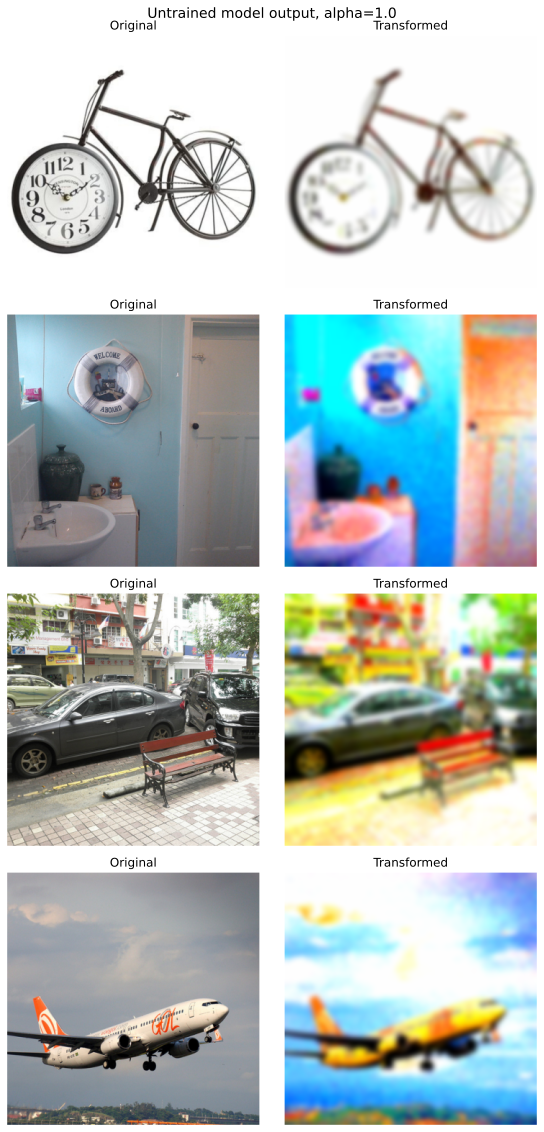

In [8]:
images, transformed, params = test_untrained_generator(
    model=model,
    dataloader=data_loader,   # your dataloader
    device=device,
    alpha_value=1.0,
    num_show=4,
)

In [54]:
def show_identity_images(data_loader, n_images=5, device=None):
    import torch
    import matplotlib.pyplot as plt
    from social_media_overlay.ext.gebhardt.image_transformations.image_transformations import apply_params

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    shown = 0

    for batch in data_loader:
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        x = x.to(device)

        for i in range(x.shape[0]):
            img = x[i:i+1, :3]

            # params = ["exposure", "saturation", "tone", "color", "contrast", "sharp", "blur"]
            params = {
                "saturation": torch.tensor([1.0], device=device, dtype=img.dtype),
                "exposure": torch.tensor([0.0], device=device, dtype=img.dtype),
                "tone": torch.ones(1, 1, 8, 1, device=device, dtype=img.dtype),
                "color": torch.ones(1, 1, 8, 1, device=device, dtype=img.dtype),
                "contrast": torch.tensor([1.0], device=device, dtype=img.dtype),
                "sharp": torch.tensor([1.0], device=device, dtype=img.dtype),
                "blur": torch.tensor([0.1], device=device, dtype=img.dtype),
            }

            y = apply_params(img, params)[-1]

            img_np = img[0].detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy()
            y_np = y[0].detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy()

            plt.figure(figsize=(8, 4))

            plt.subplot(1, 2, 1)
            plt.title("Original")
            plt.imshow(img_np)
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.title("Transformed")
            plt.imshow(y_np)
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= n_images:
                return

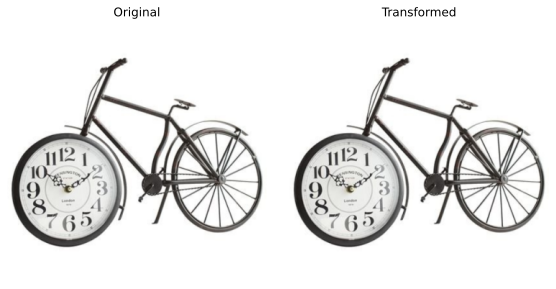

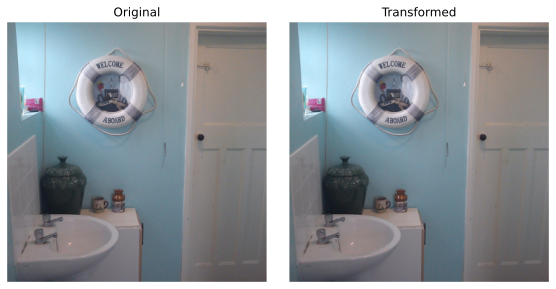

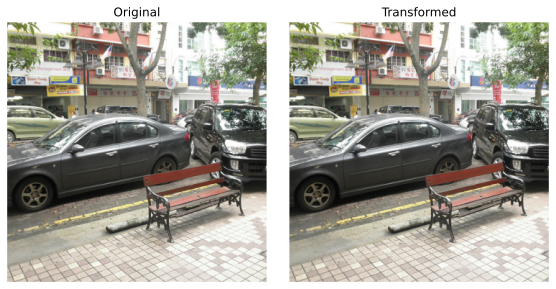

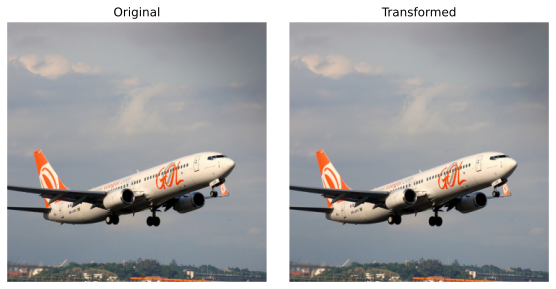

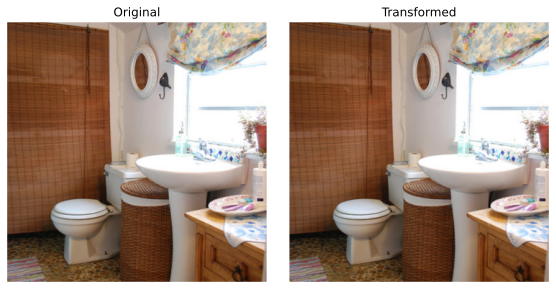

In [55]:
show_identity_images(data_loader, n_images=5)